<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasquality/oilqualityspecifications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oil quality specifications with NeqSim

This notebook turns a characterized oil assay into reproducible quality indicators and a
connected stabilization study. It is written for production, process, and flow-assurance
engineers who know basic phase equilibrium but are new to NeqSim.

**Prerequisites.** Familiarity with pressure, temperature, molar composition, density, and
viscosity is useful. All calculations use absolute pressure and SI units, with `bara` retained
where it is the conventional petroleum-engineering input unit.

**Learning objectives**

1. Build a real-component and pseudo-component oil model with `fluid_df`.
2. Calculate standard-condition density, API gravity, viscosity, and boiling-range indicators.
3. Compare true and standardized vapor-pressure metrics without treating them as interchangeable.
4. Connect NeqSim streams and unit operations in an oil-stabilization workflow.
5. Screen operating conditions against explicit product-quality, yield, and balance checks.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
from importlib.metadata import version
import platform
import subprocess

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

import neqsim
from neqsim import jneqsim
from neqsim.process import (
    clearProcess,
    heater,
    runProcess,
    separator,
    stream,
    valve,
)
from neqsim.thermo import TPflash, fluid_df, printFrame


NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#222222",
}

plt.rcParams.update(
    {
        "figure.figsize": (9.0, 5.2),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titleweight": "bold",
        "font.size": 11,
    }
)

runtime_table = pd.DataFrame(
    {
        "Software": ["NeqSim", "Python", "Java"],
        "Version used in this run": [
            NEQSIM_VERSION,
            PYTHON_VERSION,
            JAVA_VERSION,
        ],
    }
)
runtime_table

,Software,Version used in this run
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 1. Engineering context and quality vocabulary

Crude oil is a complex mixture of paraffinic, naphthenic, and aromatic hydrocarbons plus
heteroatomic compounds. A thermodynamic model does not replace a laboratory assay, but it can
connect a consistent fluid characterization to calculations used in production and processing.

The learning topics covered here are:

- **Density and API gravity** describe how heavy the oil is relative to water.
- **Viscosity** controls pumping, heat transfer, pressure loss, and separation behavior.
- **Sulfur, metals, salts, and water** are measured properties or contaminants; they are not
  predicted by the hydrocarbon equation of state unless explicitly represented and calibrated.
- **Octane and cetane numbers** apply to refined gasoline and diesel streams, not directly to
  the whole crude assay.
- **Distillation or boiling-range data** help characterize how light and heavy fractions are
  distributed.
- **Refining operations** such as distillation, cracking, hydrotreating, and reforming change
  product quality in ways that require dedicated reaction and separation models.

This notebook focuses on properties NeqSim can calculate from the stated composition and model:
density, viscosity, phase behavior, vapor pressure, flash separation, and material balance.

### Governing definitions, units, and assumptions

API gravity is defined from specific gravity at $60\,^\circ\mathrm{F}$, or
$15.56\,^\circ\mathrm{C}$. With density $\rho_o$ and reference-water density
$\rho_w$, both in $\mathrm{kg\,m^{-3}}$,

$$
{}^\circ\mathrm{API} = \frac{141.5}{\rho_o / \rho_w} - 131.5
$$

Dynamic viscosity $\mu$ is reported in $\mathrm{mPa\,s}$, numerically equal to $\mathrm{cP}$.
Kinematic viscosity $\nu$ follows from

$$
\nu = \frac{\mu}{\rho}
$$

NeqSim uses the Soave–Redlich–Kwong equation of state with the classic mixing rule in this
example. Pseudo-components represent boiling-range cuts; their molar masses and relative
densities are assay inputs, not universal constants. The example is synthetic and is intended
for workflow teaching rather than custody transfer or regulatory certification.

## 2. API gravity: interpretation

The API (American Petroleum Institute) gravity is inversely related to oil density. A higher
value describes a lighter oil. Common screening classes are:

- light crude: above 31.1 °API;
- medium crude: 22.3–31.1 °API;
- heavy crude: below 22.3 °API;
- extra-heavy crude: below 10 °API.

These boundaries are descriptive, not complete product specifications. Viscosity, vapor
pressure, water, salt, sulfur, sediment, acidity, and stability can be equally important.
Motor oils are normally classified by viscosity grades, while vegetable oils are outside the
petroleum API-gravity classification used here.

## 3. Calculation of API gravity

The next cell defines a 21-component assay and its `fluid_df` workflow. API gravity is evaluated
at the $15.56\,^\circ\mathrm{C}$ reference temperature. The named light components are followed
by 11 petroleum pseudo-components. `lastIsPlusFraction=False` means the last row is treated as a
defined pseudo-component rather than an open-ended plus fraction.

In [3]:
resfluidcomposition = {
    "ComponentName": [
        "nitrogen",
        "CO2",
        "methane",
        "ethane",
        "propane",
        "i-butane",
        "n-butane",
        "i-pentane",
        "n-pentane",
        "n-hexane",
        "C7",
        "C8",
        "C9",
        "C10-C11",
        "C12-C13",
        "C14-C15",
        "C16-C18",
        "C19-C20",
        "C21-C23",
        "C24-C29",
        "C30",
    ],
    "MolarComposition[-]": [
        0.0005948,
        0.000717,
        0.0002132,
        0.0002734,
        0.0,
        0.009535,
        1.8827,
        0.6964,
        0.8179,
        0.9106,
        1.2025,
        1.2507,
        0.7571,
        1.5015,
        1.3053,
        2.1353,
        4.4328,
        0.802,
        1.0127,
        3.4921,
        2.9922,
    ],
    "MolarMass[kg/mol]": [
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        0.09832,
        0.11227,
        0.12627,
        0.14689,
        0.174,
        0.202,
        0.237,
        0.272,
        0.307,
        0.367,
        0.594,
    ],
    "RelativeDensity[-]": [
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        0.737,
        0.758,
        0.775,
        0.794,
        0.814,
        0.830,
        0.846,
        0.860,
        0.872,
        0.889,
        0.935,
    ],
}

fluidcompositiondf = pd.DataFrame(resfluidcomposition)
fluid1 = fluid_df(
    fluidcompositiondf,
    lastIsPlusFraction=False,
)
fluid1.setMixingRule("classic")
fluid1.setMultiPhaseCheck(True)
fluid1.setPressure(1.01325, "bara")
fluid1.setTemperature(15.56, "C")

TPflash(fluid1)
fluid1.initProperties()
printFrame(fluid1)

standard_oil_density = fluid1.getPhase("oil").getDensity("kg/m3")
standard_oil_viscosity = fluid1.getPhase("oil").getViscosity("cP")
water_density_reference = 999.016
api_gravity = (
    141.5 / (standard_oil_density / water_density_reference)
    - 131.5
)

print(f"Oil density at 15.56 °C: {standard_oil_density:.3f} kg/m³")
print(f"API gravity at 60 °F: {api_gravity:.3f} °API")
print(f"Oil viscosity at 15.56 °C: {standard_oil_viscosity:.3f} cP")

                       0           1                   2 3 4 5                6
0                              total                 OIL                       
1               nitrogen  2.36002E-5          2.36002E-5        [mole fraction]
2                    CO2  2.84488E-5          2.84488E-5        [mole fraction]
3                methane  8.45927E-6          8.45927E-6        [mole fraction]
4                 ethane  1.08479E-5          1.08479E-5        [mole fraction]
5                propane         0E0                 0E0        [mole fraction]
6               i-butane  3.78326E-4          3.78326E-4        [mole fraction]
7               n-butane   7.4701E-2           7.4701E-2        [mole fraction]
8              i-pentane  2.76315E-2          2.76315E-2        [mole fraction]
9              n-pentane  3.24523E-2          3.24523E-2        [mole fraction]
10              n-hexane  3.61304E-2          3.61304E-2        [mole fraction]
11                 C7_PC  4.77123E-2    

In [4]:
input_moles = fluidcompositiondf["MolarComposition[-]"].sum()
normalized_mole_fraction = (
    fluidcompositiondf["MolarComposition[-]"] / input_moles
)
composition_residual = abs(normalized_mole_fraction.sum() - 1.0)

oil_class = "light"
if api_gravity <= 31.1:
    oil_class = "medium"
if api_gravity <= 22.3:
    oil_class = "heavy"
if api_gravity < 10.0:
    oil_class = "extra-heavy"

base_quality_table = pd.DataFrame(
    {
        "Quantity": [
            "Normalized composition sum",
            "Oil density at 15.56 °C",
            "API gravity at 60 °F",
            "Dynamic viscosity at 15.56 °C",
            "Screening class",
        ],
        "Value": [
            f"{normalized_mole_fraction.sum():.12f}",
            f"{standard_oil_density:.3f}",
            f"{api_gravity:.3f}",
            f"{standard_oil_viscosity:.3f}",
            oil_class,
        ],
        "Unit": ["mol/mol", "kg/m³", "°API", "cP", "category"],
    }
)
base_quality_table

,Quantity,Value,Unit
0,Normalized composition sum,1.000000000000,mol/mol
1,Oil density at 15.56 °C,858.982,kg/m³
2,API gravity at 60 °F,33.068,°API
3,Dynamic viscosity at 15.56 °C,16.112,cP
4,Screening class,light,category


The standard-condition flash is single-phase oil for this assay. The API classification is a
screening result; the viscosity and light-end content show why one number cannot represent all
handling or storage behavior. The composition residual is retained as the first numerical
quality check.

## 4. How NeqSim represents the workflow

`fluid_df` converts the assay table into a NeqSim thermodynamic system. Named components use
database properties, while each pseudo-component uses the supplied molar mass and relative
density. `TPflash` finds the stable phase state at specified pressure and temperature.

For stabilization, the same thermodynamic model is carried by a `stream` through a pressure
control `valve`, a temperature-setting `heater` used as a conditioner, and a `separator`.
`runProcess` solves the connected flowsheet. Product streams are then reused in the ASTM D6377
oil-quality standard calculation.

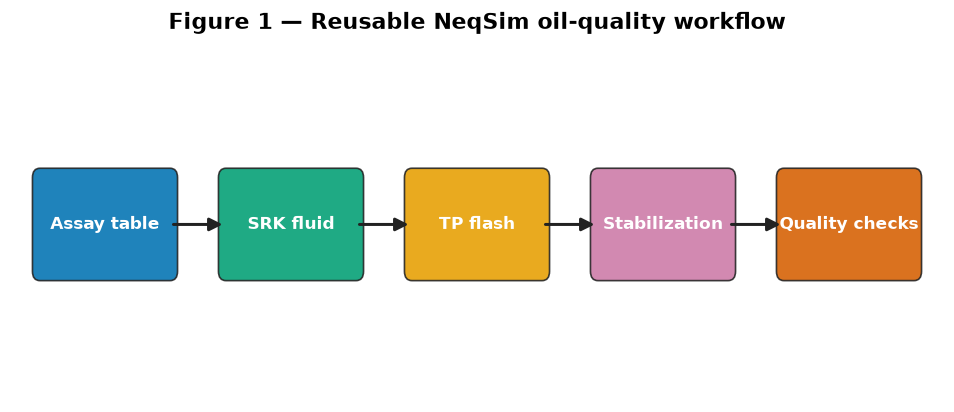

In [5]:
figure, axis = plt.subplots(figsize=(10.0, 3.8))
axis.set_xlim(0.0, 10.0)
axis.set_ylim(0.0, 3.0)
axis.axis("off")

blocks = [
    (0.3, "Assay table", COLORS["blue"]),
    (2.3, "SRK fluid", COLORS["green"]),
    (4.3, "TP flash", COLORS["orange"]),
    (6.3, "Stabilization", COLORS["purple"]),
    (8.3, "Quality checks", COLORS["red"]),
]

for x_position, label, color in blocks:
    box = FancyBboxPatch(
        (x_position, 1.1),
        1.4,
        0.8,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor=COLORS["black"],
        alpha=0.88,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.7,
        1.5,
        label,
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

for start_x in [1.7, 3.7, 5.7, 7.7]:
    arrow = FancyArrowPatch(
        (start_x, 1.5),
        (start_x + 0.6, 1.5),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.8,
        color=COLORS["black"],
    )
    axis.add_patch(arrow)

axis.set_title(
    "Figure 1 — Reusable NeqSim oil-quality workflow",
    pad=12,
)
plt.show()

The diagram emphasizes composability: the characterized fluid is not discarded after one
property calculation. It becomes the common state object for sensitivity studies, standards,
streams, equipment, products, and verification.

## 5. Composition and boiling-range audit

The input amounts are normalized internally. For normalized mole fractions $z_i$, closure is

$$
\sum_i z_i = 1
$$

Normal boiling points for named components come from the component database. Values for
pseudo-components are characterization estimates. Therefore, the chart below is a useful
boiling-range map, not a substitute for an ASTM distillation curve.

In [6]:
oil_phase = fluid1.getPhase("oil")
component_records = []

for component_index in range(oil_phase.getNumberOfComponents()):
    component = oil_phase.getComponent(component_index)
    component_records.append(
        {
            "Component": str(component.getComponentName()),
            "Mole fraction [-]": float(component.getx()),
            "Molar mass [kg/mol]": float(component.getMolarMass()),
            "Normal boiling point [°C]": (
                float(component.getNormalBoilingPoint()) - 273.15
            ),
        }
    )

component_table = pd.DataFrame(component_records)
component_table = component_table.sort_values(
    "Normal boiling point [°C]"
).reset_index(drop=True)
component_table["Cumulative mole fraction [-]"] = component_table[
    "Mole fraction [-]"
].cumsum()
component_table

,Component,Mole fraction [-],Molar mass [kg/mol],Normal boiling point [°C],Cumulative mole fraction [-]
0,nitrogen,0.000024,0.028014,-195.750000,0.000024
1,methane,0.000008,0.016043,-161.550000,0.000032
2,ethane,0.000011,0.030070,-88.550000,0.000043
3,CO2,0.000028,0.044010,-78.500000,0.000071
4,propane,0.000000,0.044097,-42.050000,0.000071
5,i-butane,0.000378,0.058123,-11.750000,0.000450
6,n-butane,0.074701,0.058123,-0.450000,0.075151
7,i-pentane,0.027631,0.072151,27.800000,0.102782
8,n-pentane,0.032452,0.072150,36.050000,0.135235
9,n-hexane,0.036130,0.086177,68.750000,0.171365


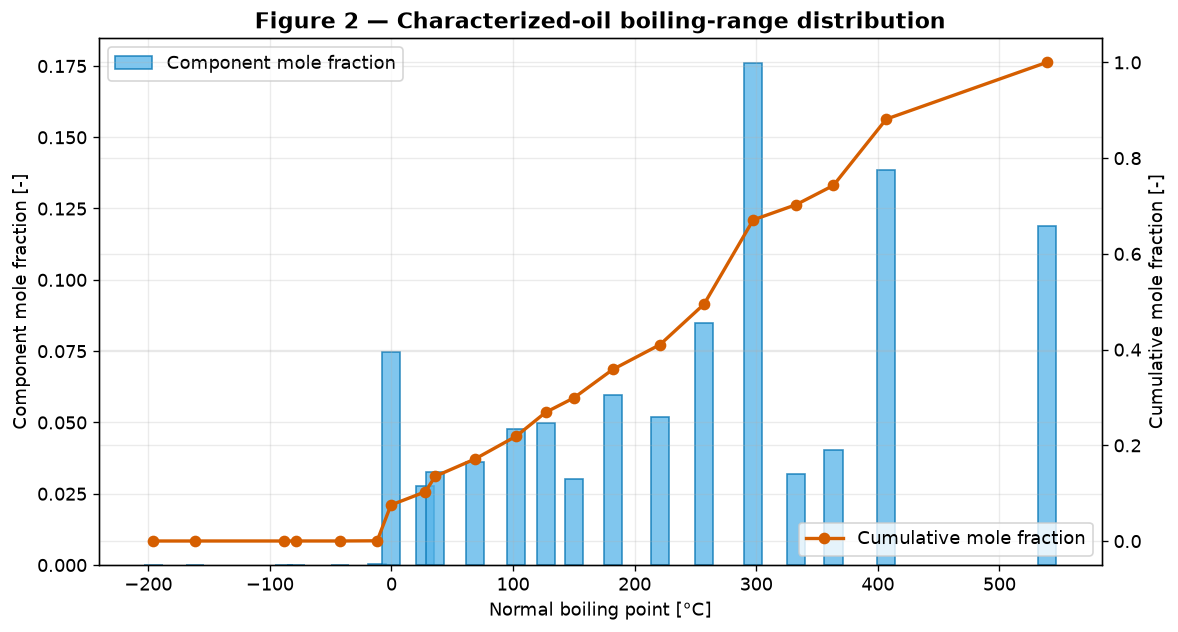

In [7]:
figure, left_axis = plt.subplots(figsize=(10.0, 5.4))
right_axis = left_axis.twinx()

left_axis.bar(
    component_table["Normal boiling point [°C]"],
    component_table["Mole fraction [-]"],
    width=15.0,
    color=COLORS["sky"],
    edgecolor=COLORS["blue"],
    alpha=0.75,
    label="Component mole fraction",
)
right_axis.plot(
    component_table["Normal boiling point [°C]"],
    component_table["Cumulative mole fraction [-]"],
    marker="o",
    color=COLORS["red"],
    linewidth=2.0,
    label="Cumulative mole fraction",
)

left_axis.set_xlabel("Normal boiling point [°C]")
left_axis.set_ylabel("Component mole fraction [-]")
right_axis.set_ylabel("Cumulative mole fraction [-]")
left_axis.set_title(
    "Figure 2 — Characterized-oil boiling-range distribution"
)
left_axis.legend(loc="upper left")
right_axis.legend(loc="lower right")
figure.tight_layout()
plt.show()

The oil spans light butanes through a heavy C30 pseudo-component. The broad distribution
explains why the fluid can combine moderate API gravity with appreciable viscosity. Heavy-end
characterization strongly affects density and viscosity; light ends dominate vapor pressure.

## 6. Temperature sensitivity

Density and viscosity are state-dependent. API gravity is formally reported only from the
$60\,^\circ\mathrm{F}$ density, so values calculated at other temperatures are labelled
**apparent API index**. The sweep uses independent clones to avoid hidden state.

In [8]:
temperature_cases_c = [5.0, 15.56, 25.0, 40.0, 60.0]
temperature_records = []

for temperature_c in temperature_cases_c:
    temperature_fluid = fluid1.clone()
    temperature_fluid.setPressure(1.01325, "bara")
    temperature_fluid.setTemperature(temperature_c, "C")
    TPflash(temperature_fluid)
    temperature_fluid.initProperties()

    oil_phase_case = temperature_fluid.getPhase("oil")
    density_kg_m3 = float(oil_phase_case.getDensity("kg/m3"))
    viscosity_cp = float(oil_phase_case.getViscosity("cP"))
    apparent_api = (
        141.5 / (density_kg_m3 / water_density_reference)
        - 131.5
    )
    kinematic_viscosity_cst = viscosity_cp * 1000.0 / density_kg_m3

    temperature_records.append(
        {
            "Temperature [°C]": temperature_c,
            "Density [kg/m³]": density_kg_m3,
            "Apparent API index [°]": apparent_api,
            "Dynamic viscosity [cP]": viscosity_cp,
            "Kinematic viscosity [cSt]": kinematic_viscosity_cst,
        }
    )

temperature_table = pd.DataFrame(temperature_records)
temperature_table

,Temperature [°C],Density [kg/m³],Apparent API index [°],Dynamic viscosity [cP],Kinematic viscosity [cSt]
0,5.00,862.943483,32.312308,22.820858,26.445368
1,15.56,858.982182,33.067749,16.112395,18.757543
2,25.00,855.304204,33.775423,12.052767,14.091790
3,40.00,849.182069,34.966968,7.877586,9.276675
4,60.00,840.456313,36.695255,4.742489,5.642755


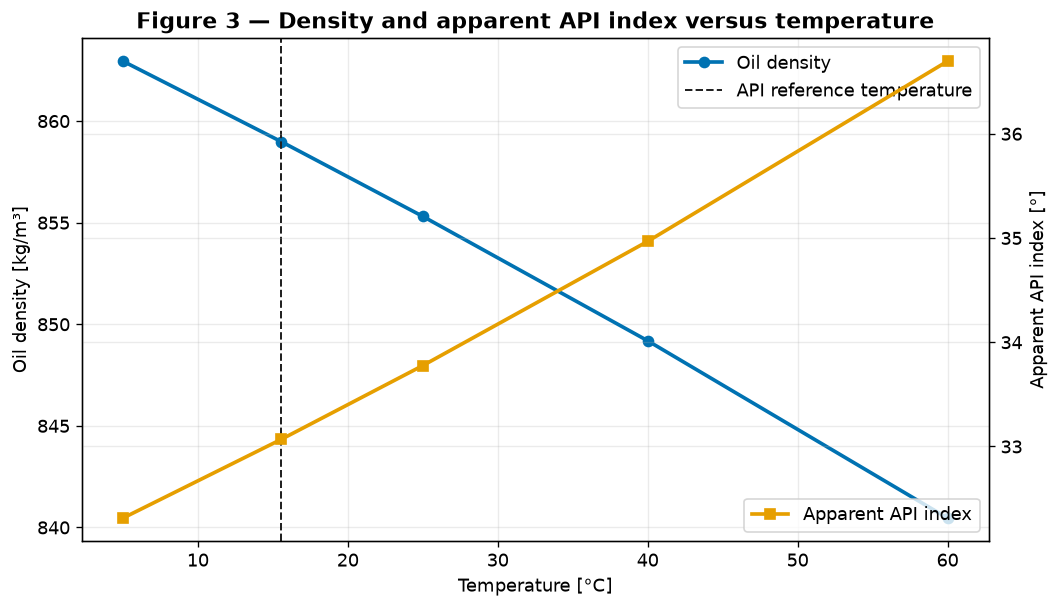

In [9]:
figure, density_axis = plt.subplots()
api_axis = density_axis.twinx()

density_axis.plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Density [kg/m³]"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2.2,
    label="Oil density",
)
api_axis.plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Apparent API index [°]"],
    marker="s",
    color=COLORS["orange"],
    linewidth=2.2,
    label="Apparent API index",
)

density_axis.axvline(
    15.56,
    color=COLORS["black"],
    linestyle="--",
    linewidth=1.2,
    label="API reference temperature",
)
density_axis.set_xlabel("Temperature [°C]")
density_axis.set_ylabel("Oil density [kg/m³]")
api_axis.set_ylabel("Apparent API index [°]")
density_axis.set_title(
    "Figure 3 — Density and apparent API index versus temperature"
)
density_axis.legend(loc="upper right")
api_axis.legend(loc="lower right")
figure.tight_layout()
plt.show()

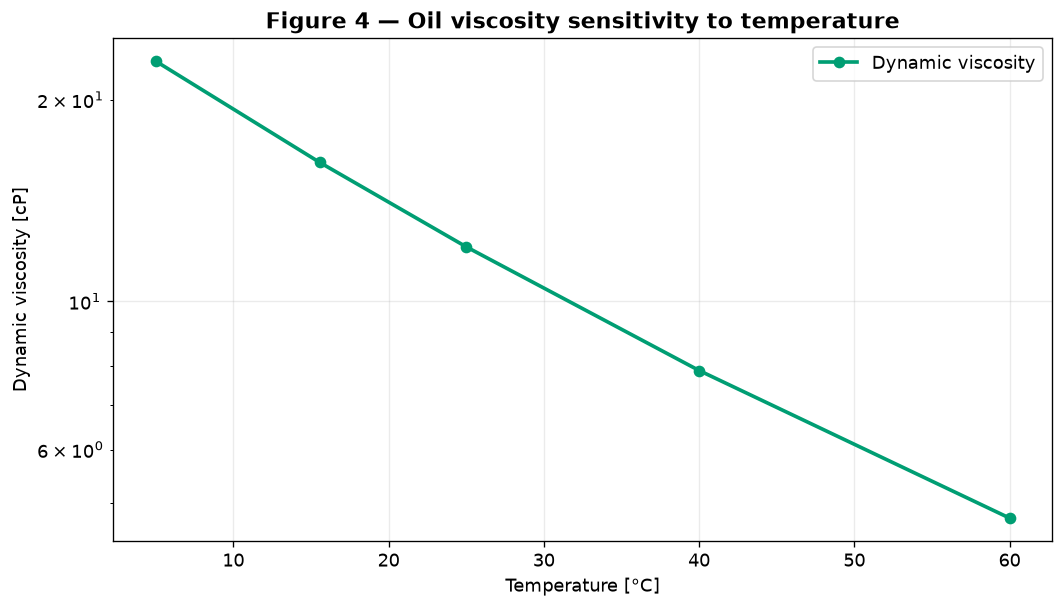

In [10]:
figure, axis = plt.subplots()
axis.semilogy(
    temperature_table["Temperature [°C]"],
    temperature_table["Dynamic viscosity [cP]"],
    marker="o",
    color=COLORS["green"],
    linewidth=2.2,
    label="Dynamic viscosity",
)
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Dynamic viscosity [cP]")
axis.set_title(
    "Figure 4 — Oil viscosity sensitivity to temperature"
)
axis.legend()
figure.tight_layout()
plt.show()

Density falls smoothly as temperature rises, while viscosity changes more strongly and is shown
on a logarithmic scale. This is the main operability lesson: a modest temperature change can
materially alter pumping behavior even though API gravity, a reference-condition property,
does not change.

## 7. Vapor pressure and ASTM D6377 methods

Vapor pressure measures light-end volatility. At fixed temperature, true vapor pressure is the
equilibrium pressure at which an infinitesimal vapor phase can coexist with the liquid:

$$
f_i^{L}(T,P,\mathbf{x}) = f_i^{V}(T,P,\mathbf{y})
$$

Here $f_i^{L}$ and $f_i^{V}$ are liquid- and vapor-phase fugacities of component $i$.
`Standard_ASTM_D6377` exposes several reported quantities. TVP, VPCR4, ASTM D6377 RVPE, and the
legacy ASTM D323 conversion are method-dependent and must be labelled rather than mixed.

In [11]:
def vapor_pressure_bara(thermo_system, method_name=None):
    standard = jneqsim.standards.oilquality.Standard_ASTM_D6377(
        thermo_system.clone()
    )
    standard.setReferenceTemperature(37.8, "C")
    if method_name is not None:
        standard.setMethodRVP(method_name)
    standard.calculate()

    value_name = "TVP"
    if method_name is not None:
        value_name = "RVP"

    return float(standard.getValue(value_name, "bara"))


vapor_pressure_methods = {
    "True vapor pressure": None,
    "VPCR4": "VPCR4",
    "RVPE, ASTM D6377": "RVP_ASTM_D6377",
    "Legacy D323 conversion": "RVP_ASTM_D323_82",
}

In [12]:
vapor_pressure_records = []

for label, method_name in vapor_pressure_methods.items():
    vapor_pressure_records.append(
        {
            "Reported quantity": label,
            "Pressure [bara]": vapor_pressure_bara(
                fluid1,
                method_name,
            ),
            "Reference temperature [°C]": 37.8,
        }
    )

vapor_pressure_table = pd.DataFrame(vapor_pressure_records)
vapor_pressure_table

,Reported quantity,Pressure [bara],Reference temperature [°C]
0,True vapor pressure,0.388848,37.8
1,VPCR4,0.327677,37.8
2,"RVPE, ASTM D6377",0.273282,37.8
3,Legacy D323 conversion,0.307113,37.8


### Light-end sensitivity

The base oil is copied and enriched with a fixed methane–ethane–propane blend. This is a
controlled synthetic scenario, not an assay correction. It isolates the expected effect of
dissolved light ends on ASTM D6377 RVPE.

,Added light ends [mol%],ASTM D6377 RVPE [bara]
0,0.000000,0.273282
1,3.355301,0.660112
2,6.492752,1.041451
3,9.432900,1.417407
4,12.193791,1.788081


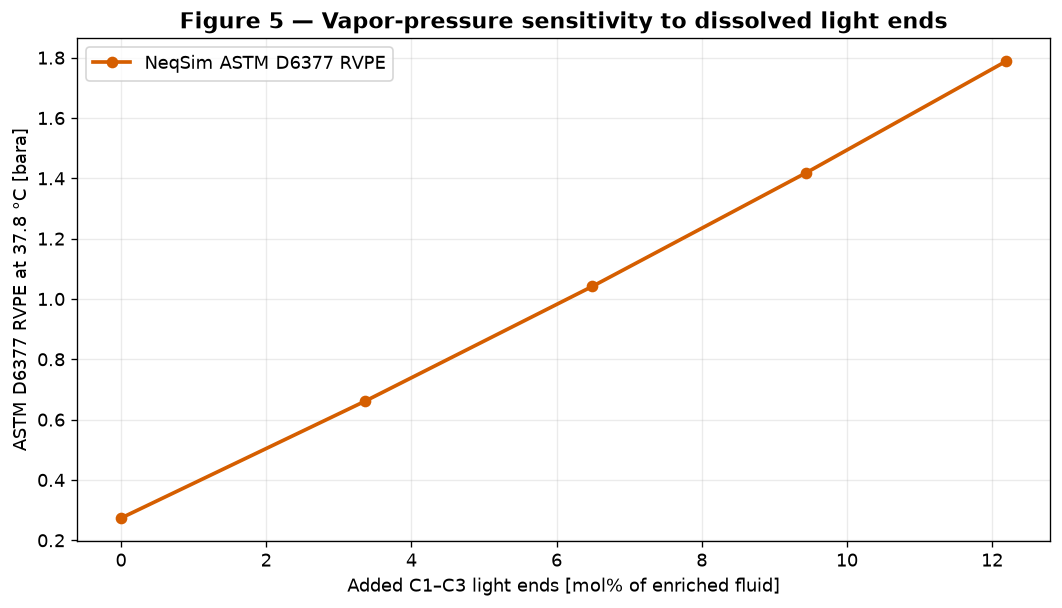

In [13]:
base_input_moles = float(
    fluidcompositiondf["MolarComposition[-]"].sum()
)
light_end_factors = [0.0, 0.25, 0.50, 0.75, 1.00]
light_end_records = []

for factor in light_end_factors:
    enriched_oil = fluid1.clone()
    methane_added = 1.0 * factor
    ethane_added = 1.0 * factor
    propane_added = 1.5 * factor
    total_added = methane_added + ethane_added + propane_added

    enriched_oil.addComponent("methane", methane_added)
    enriched_oil.addComponent("ethane", ethane_added)
    enriched_oil.addComponent("propane", propane_added)

    added_light_end_mol_percent = (
        100.0 * total_added / (base_input_moles + total_added)
    )
    rvpe_bara = vapor_pressure_bara(
        enriched_oil,
        "RVP_ASTM_D6377",
    )

    light_end_records.append(
        {
            "Added light ends [mol%]": added_light_end_mol_percent,
            "ASTM D6377 RVPE [bara]": rvpe_bara,
        }
    )

light_end_table = pd.DataFrame(light_end_records)

figure, axis = plt.subplots()
axis.plot(
    light_end_table["Added light ends [mol%]"],
    light_end_table["ASTM D6377 RVPE [bara]"],
    marker="o",
    color=COLORS["red"],
    linewidth=2.2,
    label="NeqSim ASTM D6377 RVPE",
)
axis.set_xlabel("Added C1–C3 light ends [mol% of enriched fluid]")
axis.set_ylabel("ASTM D6377 RVPE at 37.8 °C [bara]")
axis.set_title(
    "Figure 5 — Vapor-pressure sensitivity to dissolved light ends"
)
axis.legend()
figure.tight_layout()
plt.show()

light_end_table

RVPE rises monotonically with added C1–C3 material, as expected. This provides a focused
thermodynamic trend check and motivates stabilization: flashing a live oil removes volatile
components into a gas product before storage or export.

## 8. Final application: oil stabilization and export-quality screening

The final application enriches the characterized oil with a documented synthetic live-oil
increment, sets a feed rate of $100{,}000\,\mathrm{kg\,h^{-1}}$, and connects:

`feed stream → pressure-control valve → temperature conditioner → separator`.

For feed mass flow $\dot{m}_F$, oil product $\dot{m}_O$, and flash gas $\dot{m}_G$, the relative
material-balance residual is

$$
\epsilon_m = \frac{\left|\dot{m}_F-\dot{m}_O-\dot{m}_G\right|}{\dot{m}_F}
$$

Oil yield is

$$
Y_O = 100\frac{\dot{m}_O}{\dot{m}_F}
$$

The illustrative product target is ASTM D6377 RVPE at or below $0.55\,\mathrm{bara}$, with a
five-percent modeling margin giving a design limit of $0.5225\,\mathrm{bara}$. Minimum oil
yield is set to $97.0\,\mathrm{mass\%}$. These editable criteria are not regulatory limits.

In [14]:
def make_live_oil(base_oil):
    live_oil = base_oil.clone()
    live_oil.addComponent("methane", 1.0)
    live_oil.addComponent("ethane", 1.0)
    live_oil.addComponent("propane", 1.5)
    live_oil.setMixingRule("classic")
    live_oil.setMultiPhaseCheck(True)
    live_oil.setPressure(10.0, "bara")
    live_oil.setTemperature(50.0, "C")
    return live_oil


def run_stabilization_case(
    base_oil,
    separator_pressure_bara,
    separator_temperature_c,
):
    clearProcess()

    feed_stream = stream("live oil feed", make_live_oil(base_oil))
    feed_stream.setFlowRate(100000.0, "kg/hr")
    feed_stream.setPressure(10.0, "bara")
    feed_stream.setTemperature(50.0, "C")

    pressure_control_valve = valve(
        "pressure control valve",
        feed_stream,
    )
    pressure_control_valve.setOutletPressure(
        separator_pressure_bara,
        "bara",
    )

    feed_conditioner = heater(
        "feed temperature conditioner",
        pressure_control_valve.getOutletStream(),
    )
    feed_conditioner.setOutTemperature(
        separator_temperature_c,
        "C",
    )

    flash_separator = separator(
        "stabilization separator",
        feed_conditioner.getOutletStream(),
    )
    runProcess()

    oil_product = flash_separator.getLiquidOutStream()
    gas_product = flash_separator.getGasOutStream()
    feed_rate_kg_h = float(feed_stream.getFlowRate("kg/hr"))
    oil_rate_kg_h = float(oil_product.getFlowRate("kg/hr"))
    gas_rate_kg_h = float(gas_product.getFlowRate("kg/hr"))
    balance_residual = abs(
        feed_rate_kg_h - oil_rate_kg_h - gas_rate_kg_h
    ) / feed_rate_kg_h

    oil_rvpe_bara = vapor_pressure_bara(
        oil_product.getThermoSystem(),
        "RVP_ASTM_D6377",
    )

    return {
        "Separator pressure [bara]": separator_pressure_bara,
        "Separator temperature [°C]": separator_temperature_c,
        "Feed rate [kg/h]": feed_rate_kg_h,
        "Oil product [kg/h]": oil_rate_kg_h,
        "Flash gas [kg/h]": gas_rate_kg_h,
        "Oil yield [mass%]": 100.0 * oil_rate_kg_h / feed_rate_kg_h,
        "Oil ASTM D6377 RVPE [bara]": oil_rvpe_bara,
        "Mass-balance residual [-]": balance_residual,
        "Feed stream": feed_stream,
        "Oil stream": oil_product,
        "Gas stream": gas_product,
    }

In [15]:
base_stabilization_result = run_stabilization_case(
    fluid1,
    separator_pressure_bara=2.0,
    separator_temperature_c=60.0,
)

base_application_table = pd.DataFrame(
    {
        "Quantity": [
            "Feed rate",
            "Stabilized oil rate",
            "Flash-gas rate",
            "Oil yield",
            "ASTM D6377 RVPE",
            "Relative mass-balance residual",
        ],
        "Value": [
            base_stabilization_result["Feed rate [kg/h]"],
            base_stabilization_result["Oil product [kg/h]"],
            base_stabilization_result["Flash gas [kg/h]"],
            base_stabilization_result["Oil yield [mass%]"],
            base_stabilization_result[
                "Oil ASTM D6377 RVPE [bara]"
            ],
            base_stabilization_result[
                "Mass-balance residual [-]"
            ],
        ],
        "Unit": [
            "kg/h",
            "kg/h",
            "kg/h",
            "mass%",
            "bara",
            "-",
        ],
    }
)
base_application_table

,Quantity,Value,Unit
0,Feed rate,1.000000e+05,kg/h
1,Stabilized oil rate,9.785483e+04,kg/h
2,Flash-gas rate,2.145168e+03,kg/h
3,Oil yield,9.785483e+01,mass%
4,ASTM D6377 RVPE,5.122050e-01,bara
5,Relative mass-balance residual,5.366019e-16,-


### Pressure–temperature scenario analysis

Lower separator pressure or higher temperature removes more light material and lowers product
RVPE, but usually sacrifices oil yield. The grid below varies both decisions while keeping the
feed, fluid model, and equipment sequence fixed.

In [16]:
separator_pressures_bara = [1.2, 1.5, 2.0, 3.0, 5.0]
separator_temperatures_c = [40.0, 60.0, 80.0]
stabilization_records = []

for separator_temperature_c in separator_temperatures_c:
    for separator_pressure_bara in separator_pressures_bara:
        case_result = run_stabilization_case(
            fluid1,
            separator_pressure_bara,
            separator_temperature_c,
        )
        stabilization_records.append(
            {
                key: value
                for key, value in case_result.items()
                if not key.endswith("stream")
                and not key.endswith("Stream")
            }
        )

stabilization_table = pd.DataFrame(stabilization_records)
stabilization_table

,Separator pressure [bara],Separator temperature [°C],Feed rate [kg/h],Oil product [kg/h],Flash gas [kg/h],Oil yield [mass%],Oil ASTM D6377 RVPE [bara],Mass-balance residual [-]
0,1.2,40.0,100000.0,97821.568535,2178.431465,97.821569,0.464372,2.637535e-16
1,1.5,40.0,100000.0,98159.252144,1840.747856,98.159252,0.547685,9.817404e-13
2,2.0,40.0,100000.0,98555.553901,1444.446099,98.555554,0.669109,9.884616e-13
3,3.0,40.0,100000.0,99027.560564,972.439436,99.027561,0.865238,1.381875e-13
4,5.0,40.0,100000.0,99478.088117,521.911883,99.478088,1.151737,9.945802e-13
5,1.2,60.0,100000.0,96921.017759,3078.982241,96.921018,0.333856,1.136868e-16
6,1.5,60.0,100000.0,97339.611140,2660.388860,97.339611,0.404346,3.956302e-16
7,2.0,60.0,100000.0,97854.831793,2145.168207,97.854832,0.512205,5.366019e-16
8,3.0,60.0,100000.0,98506.634140,1493.365860,98.506634,0.698138,7.146355e-15
9,5.0,60.0,100000.0,99163.991813,836.008186,99.163992,0.987657,2.785916e-12


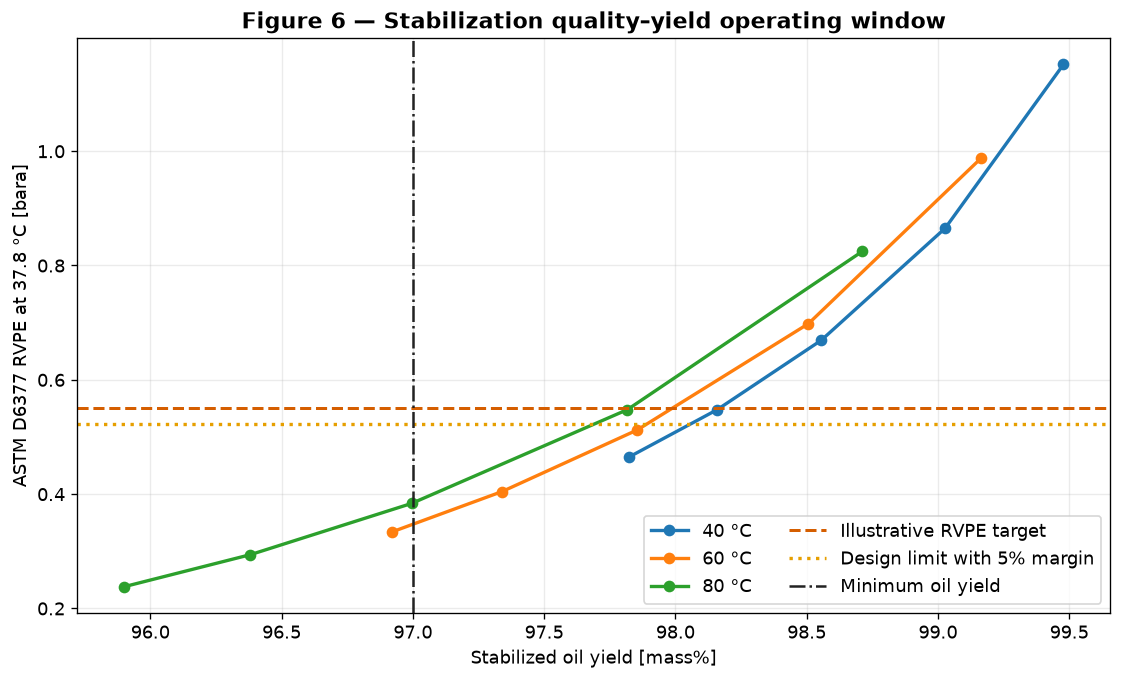

In [17]:
rvpe_target_bara = 0.55
rvpe_design_limit_bara = 0.95 * rvpe_target_bara
minimum_oil_yield_mass_percent = 97.0

figure, axis = plt.subplots(figsize=(9.5, 5.8))

for temperature_c, group in stabilization_table.groupby(
    "Separator temperature [°C]"
):
    axis.plot(
        group["Oil yield [mass%]"],
        group["Oil ASTM D6377 RVPE [bara]"],
        marker="o",
        linewidth=2.0,
        label=f"{temperature_c:.0f} °C",
    )

axis.axhline(
    rvpe_target_bara,
    color=COLORS["red"],
    linestyle="--",
    linewidth=1.8,
    label="Illustrative RVPE target",
)
axis.axhline(
    rvpe_design_limit_bara,
    color=COLORS["orange"],
    linestyle=":",
    linewidth=2.0,
    label="Design limit with 5% margin",
)
axis.axvline(
    minimum_oil_yield_mass_percent,
    color=COLORS["black"],
    linestyle="-.",
    linewidth=1.5,
    label="Minimum oil yield",
)
axis.set_xlabel("Stabilized oil yield [mass%]")
axis.set_ylabel("ASTM D6377 RVPE at 37.8 °C [bara]")
axis.set_title(
    "Figure 6 — Stabilization quality–yield operating window"
)
axis.legend(ncol=2)
figure.tight_layout()
plt.show()

In [18]:
feasible_cases = stabilization_table[
    (
        stabilization_table["Oil ASTM D6377 RVPE [bara]"]
        <= rvpe_design_limit_bara
    )
    & (
        stabilization_table["Oil yield [mass%]"]
        >= minimum_oil_yield_mass_percent
    )
].copy()

selected_case = feasible_cases.sort_values(
    [
        "Oil yield [mass%]",
        "Oil ASTM D6377 RVPE [bara]",
    ],
    ascending=[False, True],
).iloc[0]

decision_table = pd.DataFrame(
    {
        "Decision item": [
            "Selected separator pressure",
            "Selected separator temperature",
            "Predicted oil yield",
            "Predicted ASTM D6377 RVPE",
            "RVPE design limit",
            "Maximum mass-balance residual in grid",
        ],
        "Value": [
            selected_case["Separator pressure [bara]"],
            selected_case["Separator temperature [°C]"],
            selected_case["Oil yield [mass%]"],
            selected_case["Oil ASTM D6377 RVPE [bara]"],
            rvpe_design_limit_bara,
            stabilization_table[
                "Mass-balance residual [-]"
            ].max(),
        ],
        "Unit": [
            "bara",
            "°C",
            "mass%",
            "bara",
            "bara",
            "-",
        ],
    }
)
decision_table

,Decision item,Value,Unit
0,Selected separator pressure,2.000000e+00,bara
1,Selected separator temperature,6.000000e+01,°C
2,Predicted oil yield,9.785483e+01,mass%
3,Predicted ASTM D6377 RVPE,5.122050e-01,bara
4,RVPE design limit,5.225000e-01,bara
5,Maximum mass-balance residual in grid,1.069347e-11,-


The selected case maximizes predicted oil yield among grid points that pass both the RVPE design
limit and the minimum-yield criterion. It is an auditable screening decision, not a global
optimizer. A project model should add heat duty, compressor or vapor-recovery constraints,
equipment capacity, emissions, water handling, and uncertainty.

## 9. Verification checks

The notebook uses conservation and expected trends rather than an invented benchmark. Important
checks are composition closure, finite positive properties, decreasing density and viscosity
with temperature, increasing RVPE with added light ends, and process mass closure.

In [19]:
engineering_checks = {
    "composition closes": composition_residual < 1.0e-12,
    "standard density is finite": np.isfinite(standard_oil_density),
    "standard density is physically plausible": (
        700.0 < standard_oil_density < 1000.0
    ),
    "API gravity is physically plausible": 5.0 < api_gravity < 60.0,
    "viscosity is positive": standard_oil_viscosity > 0.0,
    "temperature density trend": (
        np.diff(temperature_table["Density [kg/m³]"]) < 0.0
    ).all(),
    "temperature viscosity trend": (
        np.diff(temperature_table["Dynamic viscosity [cP]"]) < 0.0
    ).all(),
    "light-end RVPE trend": light_end_table[
        "ASTM D6377 RVPE [bara]"
    ].is_monotonic_increasing,
    "all vapor pressures are finite": np.isfinite(
        vapor_pressure_table["Pressure [bara]"]
    ).all(),
    "all process results are finite": np.isfinite(
        stabilization_table.select_dtypes(include=[np.number])
    ).all().all(),
    "process mass balances close": (
        stabilization_table["Mass-balance residual [-]"].max()
        < 1.0e-9
    ),
    "at least one design case is feasible": not feasible_cases.empty,
    "selected case passes RVPE margin": (
        selected_case["Oil ASTM D6377 RVPE [bara]"]
        <= rvpe_design_limit_bara
    ),
    "selected case passes yield criterion": (
        selected_case["Oil yield [mass%]"]
        >= minimum_oil_yield_mass_percent
    ),
    "low pressure improves volatility": (
        stabilization_table[
            stabilization_table["Separator temperature [°C]"] == 60.0
        ]
        .sort_values("Separator pressure [bara]")[
            "Oil ASTM D6377 RVPE [bara]"
        ]
        .is_monotonic_increasing
    ),
}

failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not passed
]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

check_table = pd.DataFrame(
    {
        "Engineering check": list(engineering_checks),
        "Status": [
            "PASS" if passed else "FAIL"
            for passed in engineering_checks.values()
        ],
    }
)
print(f"{len(engineering_checks)} engineering checks passed.")
check_table

15 engineering checks passed.


,Engineering check,Status
0,composition closes,PASS
1,standard density is finite,PASS
2,standard density is physically plausible,PASS
3,API gravity is physically plausible,PASS
4,viscosity is positive,PASS
5,temperature density trend,PASS
6,temperature viscosity trend,PASS
7,light-end RVPE trend,PASS
8,all vapor pressures are finite,PASS
9,all process results are finite,PASS


## 10. Validity limits and practical limitations

- SRK with a classic mixing rule is a transparent hydrocarbon screening model. Calibrate
  pseudo-components and binary interactions against assay and PVT data for design work.
- The synthetic live-oil increment demonstrates workflow sensitivity; it is not field data.
- ASTM D6377 calculations here are model predictions. Laboratory sampling and the applicable
  contractual standard govern acceptance.
- Sulfur, salt, basic sediment and water, acidity, metals, wax appearance, asphaltene stability,
  pour point, octane, and cetane require additional composition, tests, or specialist models.
- The separator is an equilibrium stage with no residence-time, entrainment, heat-transfer,
  or control-system model.
- Pressure is absolute. Flow rates are mass flow at the process stream, not standard liquid
  volumes.

## 11. Troubleshooting

- If a pseudo-component fails to initialize, check that its molar mass is in `kg/mol`, its
  relative density is dimensionless, and its name is unique.
- If `getPhase("oil")` fails, inspect the flash result and phase names; the chosen state may not
  contain an oil phase.
- If a standard calculation returns an unexpected value, confirm the reference temperature,
  selected method name, pressure unit, and light-end composition.
- If a process case does not close, verify that all equipment is connected through outlet
  streams and call `runProcess()` after changing conditions.
- Rebuild each scenario from a clone or a new process so prior state cannot leak into the next
  calculation.

## 12. Summary

The characterized-oil calculation forms a complete NeqSim workflow. The SRK fluid model
supports standard-condition API gravity and
viscosity, boiling-range inspection, ASTM D6377 vapor-pressure calculations, controlled
light-end sensitivity, and a connected stabilization flowsheet. Explicit assertions make the
quality–yield decision reproducible and expose the assumptions that must be replaced for a real
asset.

## 13. Further exercises

1. Replace the synthetic composition with a public or authorized assay and compare modeled
   density and viscosity with laboratory values.
2. Characterize the final row as a true plus fraction and quantify its effect on API gravity.
3. Add water and an aqueous-compatible model, then assess three-phase separation.
4. Add heat duty and vapor-recovery compression to the stabilization decision.
5. Replace the fixed pressure–temperature grid with an optimizer and uncertainty bands.
6. Compare SRK with Peng–Robinson while keeping characterization and acceptance criteria fixed.

## 14. Authoritative references

- NeqSim project and source: https://github.com/equinor/neqsim
- NeqSim Python package examples: https://github.com/equinor/neqsimpython
- NeqSim Colab catalog: https://github.com/EvenSol/NeqSim-Colab
- ASTM D6377, *Standard Test Method for Determination of Vapor Pressure of Crude Oil:
  VPCRx-F(Tm°C)*, ASTM International.
- ASTM D4052, *Standard Test Method for Density, Relative Density, and API Gravity of Liquids by
  Digital Density Meter*, ASTM International.
- API Technical Data Book—Petroleum Refining, American Petroleum Institute.

Always use the edition and acceptance limits named in the governing project or sales
specification.